### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

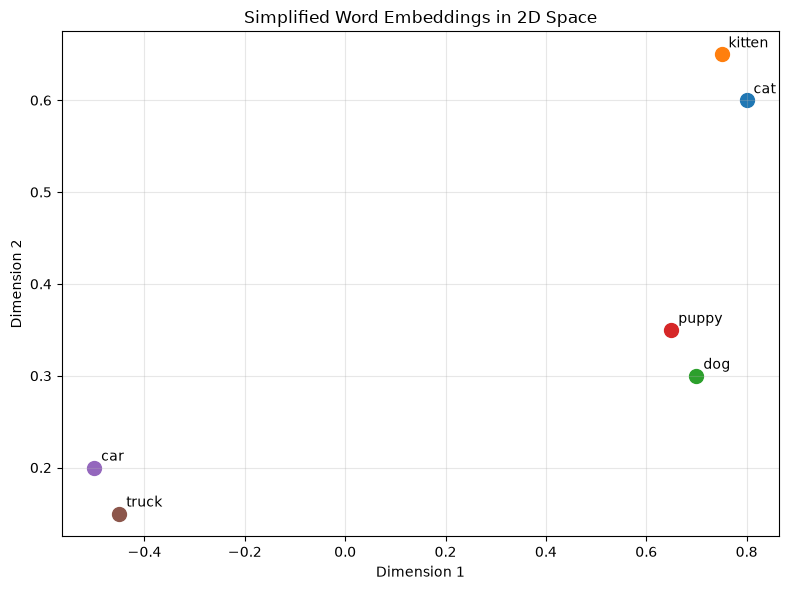

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)

    return dot_product / (norm_a * norm_b)

In [6]:
 # Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [7]:
cosine_similarity(cat_vector,car_vector)

-0.43718588548916804

## Create you first embedding model

In [8]:
# Hugging Face and OpenAI models

from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a simple embedding model
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

embeddings

/Users/tuhindas/Udemy RAGCourse/Data_Ingest_Parse/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
## create your first embeddings
text = "Hello, I am learning about embeddings!"

embedding = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)


Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.018163280561566353, -0.09955170005559921, 0.013816107995808125, -0.008125950582325459, 0.014152215793728828, 0.06406485289335251, -0.0062533216550946236, -0.003017913084477186, 0.02528725378215313, -0.020198671147227287, 0.02432973124086857, 0.07435058057308197, 0.05117717385292053, 0.022038422524929047, -0.05830615386366844, 0.015268281102180481, 0.023584427312016487, 0.09455397725105286, -0.06508846580982208, 0.013296645134687424, -0.020497595891356468, -0.05690852180123329, 0.03030332550406456, -0.08365615457296371, 0.026596326380968094, -0.01523146778345108, -0.04361538961529732, 0.053983964025974274, 0.09025716781616211, -0.08893880993127823, 0.03964460268616676, -0.00883504282683134, -0.030343735590577126, 0.07425562292337418, -0.05409916862845421, 0.11107998341321945, 0.036899879574775696, -0.008959795348346233, -0.06140243262052536, -0.0031433196272701025, 0.02195819281041622, 0.0422082357108593, -0.0289378

In [12]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence = embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018199443817, -0.01187015138566494, -0.028117051348090172, 0.05123862624168396, -0.05597444996237755, 0.030191566795110703, 0.03016132302582264, 0.02469838596880436, -0.01837053894996643, 0.05876680091023445, -0.024953175336122513, 0.06015423685312271, 0.0398317351937294, 0.03323051333427429, -0.06131139397621155, -0.049373116344213486, -0.05486351251602173, -0.04007609188556671, 0.056429147720336914, 0.039156585931777954, -0.03473709896206856, -0.013247698545455933, 0.031966183334589005, -0.06349919736385345, -0.06017858162522316, 0.07823453098535538, -0.0283038429915905, -0.04744282737374306, 0.04035927727818489, -0.006630877032876015, -0.06674094498157501, -0.004191351123154163, -0.025311654433608055, 0.053341660648584366, 0.017428096383810043, -0.09792359173297882, 0.006061306223273277, -0.06524167954921722, 0.04557255655527115, 0.023641783744096756, 0.07658485323190689, -0.010264311917126179, -0.00407679658383131, -0.062322814017534256, 0.03370526060461998, 0.01866115257143

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

